In [42]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [43]:
chunks = pd.read_csv("/kaggle/input/datasets/shanegerami/ai-vs-human-text/AI_Human.csv", chunksize=100000)
human_list, ai_list = [], []

for chunk in chunks:
    human_list.append(chunk[chunk['generated'] == 0.0])
    ai_list.append(chunk[chunk['generated'] == 1.0])
    if sum(len(x) for x in human_list) >= 10000 and sum(len(x) for x in ai_list) >= 10000:
        break

df1 = pd.concat([
    pd.concat(human_list).iloc[:10000],
    pd.concat(ai_list).iloc[:10000]
]).sample(frac=1, random_state=42).reset_index(drop=True)

df1.rename(columns={'generated': 'label'}, inplace=True)
df1 = df1[['text', 'label']]
df1['label'] = df1['label'].astype(int)
df1.head()

,text,label
0,"Dear Senator [Your Senator's Name],\n\nI hope ...",1
1,"PHONES & DRIVING\n\nIn the United States , car...",0
2,The face on Mars is just another fake thing ha...,0
3,I believe that we should change the system to ...,0
4,\nRalph Waldo Emerson is well known for his mu...,1


In [44]:
df2 = pd.read_csv("/kaggle/input/datasets/thedrcat/daigt-v2-train-dataset/train_v2_drcat_02.csv")
df2 = df2[['text', 'label']]
df2.head()

,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


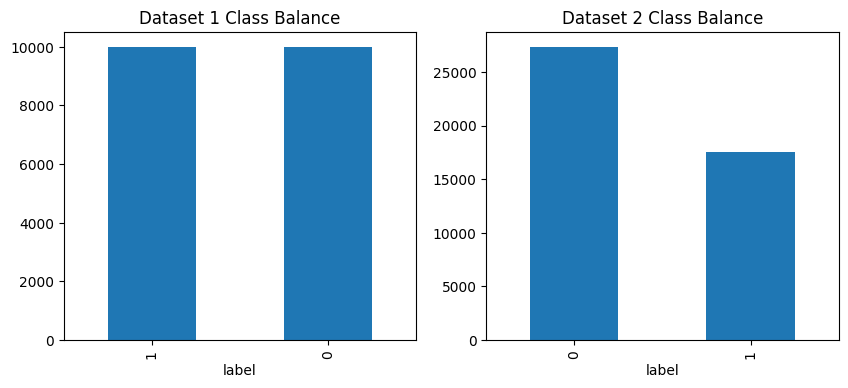

(20000, 2) (44868, 2)
count    20000.000000
mean      2095.748850
std        957.371204
min          1.000000
25%       1362.000000
50%       2014.000000
75%       2585.000000
max       9157.000000
Name: text, dtype: float64
count    44868.000000
mean      2216.222921
std        969.928064
min         48.000000
25%       1564.750000
50%       2044.000000
75%       2619.000000
max      18322.000000
Name: text, dtype: float64


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df1['label'].value_counts().plot(kind='bar', ax=axes[0], title='Dataset 1 Class Balance')
df2['label'].value_counts().plot(kind='bar', ax=axes[1], title='Dataset 2 Class Balance')
plt.show()

print(df1.shape, df2.shape)
print(df1['text'].str.len().describe())
print(df2['text'].str.len().describe())

In [46]:

import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    doc = nlp(' '.join(tokens))
    lemmatized = [token.lemma_ for token in doc]
    return ' '.join(lemmatized)

In [47]:
df1['clean_text'] = df1['text'].apply(clean_text)
df1.head()

,text,label,clean_text
0,"Dear Senator [Your Senator's Name],\n\nI hope ...",1,dear senator senator name hope letter find wel...
1,"PHONES & DRIVING\n\nIn the United States , car...",0,phone drive united states car wrecks distract ...
2,The face on Mars is just another fake thing ha...,0,face mar another fake thing happen world hones...
3,I believe that we should change the system to ...,0,believe change system election popular vote ch...
4,\nRalph Waldo Emerson is well known for his mu...,1,ralph waldo emerson well know musing foolish c...


In [48]:
df2['clean_text'] = df2['text'].apply(clean_text)
df2.head()

,text,label,clean_text
0,Phones\n\nModern humans today are always on th...,0,phone modern human today always phone always p...
1,This essay will explain if drivers should or s...,0,essay explain driver able use electronic devic...
2,Driving while the use of cellular devices\n\nT...,0,drive use cellular device today society though...
3,Phones & Driving\n\nDrivers should not be able...,0,phone drive driver able use phone operating ve...
4,Cell Phone Operation While Driving\n\nThe abil...,0,cell phone operation driving ability stay conn...


In [49]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    df1['clean_text'], df1['label'], test_size=0.2, random_state=42, stratify=df1['label']
)
print(X1_train.shape, X1_test.shape)

(16000,) (4000,)


In [50]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    df2['clean_text'], df2['label'], test_size=0.2, random_state=42, stratify=df2['label']
)
print(X2_train.shape, X2_test.shape)

(35894,) (8974,)


In [51]:
bow_vec1 = CountVectorizer()
X1_train_bow = bow_vec1.fit_transform(X1_train)
X1_test_bow = bow_vec1.transform(X1_test)

tfidf_vec1 = TfidfVectorizer()
X1_train_tfidf = tfidf_vec1.fit_transform(X1_train)
X1_test_tfidf = tfidf_vec1.transform(X1_test)
print(X1_train_bow.shape)

(16000, 49323)


In [52]:
bow_vec2 = CountVectorizer()
X2_train_bow = bow_vec2.fit_transform(X2_train)
X2_test_bow = bow_vec2.transform(X2_test)

tfidf_vec2 = TfidfVectorizer()
X2_train_tfidf = tfidf_vec2.fit_transform(X2_train)
X2_test_tfidf = tfidf_vec2.transform(X2_test)
print(X2_train_bow.shape)

(35894, 68645)


In [53]:
results = []

def evaluate_model(model_name, representation, dataset_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    results.append({
        'Algorithm': model_name,
        'Representation': representation,
        'Dataset': dataset_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

In [54]:
nb_bow1 = MultinomialNB()
nb_bow1.fit(X1_train_bow, y1_train)
pred = nb_bow1.predict(X1_test_bow)
evaluate_model('Naive Bayes', 'BoW', 'Dataset 1', y1_test, pred)
print(f"Naive Bayes (BoW) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Naive Bayes (BoW) - Dataset 1 Accuracy: 0.9698


In [55]:
nb_tfidf1 = MultinomialNB()
nb_tfidf1.fit(X1_train_tfidf, y1_train)
pred = nb_tfidf1.predict(X1_test_tfidf)
evaluate_model('Naive Bayes', 'TF-IDF', 'Dataset 1', y1_test, pred)
print(f"Naive Bayes (TF-IDF) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Naive Bayes (TF-IDF) - Dataset 1 Accuracy: 0.9702


In [56]:
lr_bow1 = LogisticRegression(max_iter=1000)
lr_bow1.fit(X1_train_bow, y1_train)
pred = lr_bow1.predict(X1_test_bow)
evaluate_model('Logistic Regression', 'BoW', 'Dataset 1', y1_test, pred)
print(f"Logistic Regression (BoW) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Logistic Regression (BoW) - Dataset 1 Accuracy: 0.9972


In [57]:
lr_tfidf1 = LogisticRegression(max_iter=1000)
lr_tfidf1.fit(X1_train_tfidf, y1_train)
pred = lr_tfidf1.predict(X1_test_tfidf)
evaluate_model('Logistic Regression', 'TF-IDF', 'Dataset 1', y1_test, pred)
print(f"Logistic Regression (TF-IDF) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Logistic Regression (TF-IDF) - Dataset 1 Accuracy: 0.9930


In [58]:
svm_bow1 = LinearSVC(max_iter=5000)
svm_bow1.fit(X1_train_bow, y1_train)
pred = svm_bow1.predict(X1_test_bow)
evaluate_model('Support Vector Machine', 'BoW', 'Dataset 1', y1_test, pred)
print(f"Support Vector Machine (BoW) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Support Vector Machine (BoW) - Dataset 1 Accuracy: 0.9962


In [59]:
svm_tfidf1 = LinearSVC(max_iter=5000)
svm_tfidf1.fit(X1_train_tfidf, y1_train)
pred = svm_tfidf1.predict(X1_test_tfidf)
evaluate_model('Support Vector Machine', 'TF-IDF', 'Dataset 1', y1_test, pred)
print(f"Support Vector Machine (TF-IDF) - Dataset 1 Accuracy: {accuracy_score(y1_test, pred):.4f}")

Support Vector Machine (TF-IDF) - Dataset 1 Accuracy: 0.9985


In [60]:
nb_bow2 = MultinomialNB()
nb_bow2.fit(X2_train_bow, y2_train)
pred = nb_bow2.predict(X2_test_bow)
evaluate_model('Naive Bayes', 'BoW', 'Dataset 2', y2_test, pred)
print(f"Naive Bayes (BoW) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Naive Bayes (BoW) - Dataset 2 Accuracy: 0.9590


In [61]:
nb_tfidf2 = MultinomialNB()
nb_tfidf2.fit(X2_train_tfidf, y2_train)
pred = nb_tfidf2.predict(X2_test_tfidf)
evaluate_model('Naive Bayes', 'TF-IDF', 'Dataset 2', y2_test, pred)
print(f"Naive Bayes (TF-IDF) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Naive Bayes (TF-IDF) - Dataset 2 Accuracy: 0.9505


In [62]:
lr_bow2 = LogisticRegression(max_iter=1000)
lr_bow2.fit(X2_train_bow, y2_train)
pred = lr_bow2.predict(X2_test_bow)
evaluate_model('Logistic Regression', 'BoW', 'Dataset 2', y2_test, pred)
print(f"Logistic Regression (BoW) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Logistic Regression (BoW) - Dataset 2 Accuracy: 0.9920


In [63]:
lr_tfidf2 = LogisticRegression(max_iter=1000)
lr_tfidf2.fit(X2_train_tfidf, y2_train)
pred = lr_tfidf2.predict(X2_test_tfidf)
evaluate_model('Logistic Regression', 'TF-IDF', 'Dataset 2', y2_test, pred)
print(f"Logistic Regression (TF-IDF) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Logistic Regression (TF-IDF) - Dataset 2 Accuracy: 0.9881


In [64]:
svm_bow2 = LinearSVC(max_iter=30000)
svm_bow2.fit(X2_train_bow, y2_train)
pred = svm_bow2.predict(X2_test_bow)
evaluate_model('Support Vector Machine', 'BoW', 'Dataset 2', y2_test, pred)
print(f"Support Vector Machine (BoW) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Support Vector Machine (BoW) - Dataset 2 Accuracy: 0.9893


In [65]:
svm_tfidf2 = LinearSVC(max_iter=5000)
svm_tfidf2.fit(X2_train_tfidf, y2_train)
pred = svm_tfidf2.predict(X2_test_tfidf)
evaluate_model('Support Vector Machine', 'TF-IDF', 'Dataset 2', y2_test, pred)
print(f"Support Vector Machine (TF-IDF) - Dataset 2 Accuracy: {accuracy_score(y2_test, pred):.4f}")

Support Vector Machine (TF-IDF) - Dataset 2 Accuracy: 0.9940


In [66]:
results_df = pd.DataFrame(results)
results_df

,Algorithm,Representation,Dataset,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,BoW,Dataset 1,0.9698,0.9825,0.9565,0.9693
1,Naive Bayes,TF-IDF,Dataset 1,0.9702,0.9840,0.9560,0.9698
2,Logistic Regression,BoW,Dataset 1,0.9972,0.9975,0.9970,0.9972
3,Logistic Regression,TF-IDF,Dataset 1,0.9930,0.9975,0.9885,0.9930
4,Support Vector Machine,BoW,Dataset 1,0.9962,0.9960,0.9965,0.9963
5,Support Vector Machine,TF-IDF,Dataset 1,0.9985,0.9990,0.9980,0.9985
6,Naive Bayes,BoW,Dataset 2,0.9590,0.9675,0.9260,0.9463
7,Naive Bayes,TF-IDF,Dataset 2,0.9505,0.9796,0.8917,0.9336
8,Logistic Regression,BoW,Dataset 2,0.9920,0.9914,0.9880,0.9897
9,Logistic Regression,TF-IDF,Dataset 2,0.9881,0.9916,0.9777,0.9846


In [67]:
pivot_table = results_df.pivot_table(index=['Algorithm', 'Representation'], columns='Dataset', values='Accuracy')
pivot_table

Dataset                                Dataset 1  Dataset 2
Algorithm              Representation                      
Logistic Regression    BoW                0.9972     0.9920
                       TF-IDF             0.9930     0.9881
Naive Bayes            BoW                0.9698     0.9590
                       TF-IDF             0.9702     0.9505
Support Vector Machine BoW                0.9962     0.9893
                       TF-IDF             0.9985     0.9940

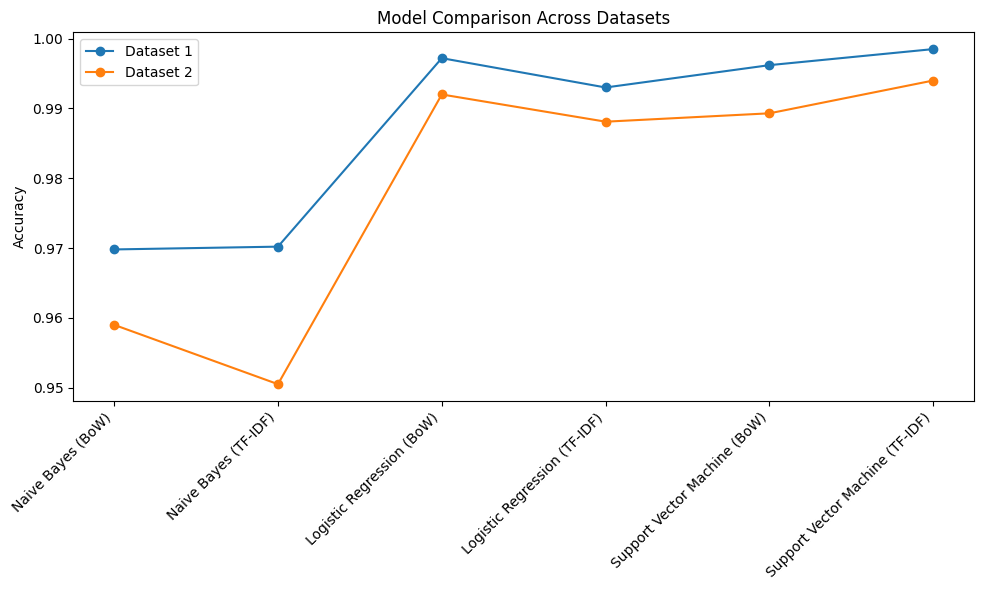

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, group in results_df.groupby('Dataset'):
    ax.plot(group['Algorithm'] + ' (' + group['Representation'] + ')', group['Accuracy'], marker='o', label=name)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison Across Datasets')
ax.legend()
plt.tight_layout()
plt.show()